Gabriela Bułat
Jakub Grzyb

state after project class on 19.05.2026

# Animated 2D Cloud Lifecycle Simulation (PySDM)
This notebook fixes the spatial axes orientation via transposition, includes a
speed-toggle for fast testing, and generates a fluid animated GIF of the cloud.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display
from tqdm import tqdm

# Enforce stable threading layer for PySDM / Numba
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'

if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils PySDM-examples PySDM matplotlib numpy tqdm pillow
    from open_atmos_jupyter_utils import pip_install_on_colab

from PySDM_examples.Arabas_et_al_2015 import Settings, SpinUp
from PySDM_examples.utils.kinematic_2d import Storage, Simulation
import PySDM.products as PySDM_products
from PySDM import Formulae
from PySDM.physics import si

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.2/172.2 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.1/339.1 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.0/763.0 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.9 MB/s eta 0:00:00


## 1. Configuration (Speed Toggle)
Toggle `FAST_TEST_MODE = True` to shrink the grid and super-droplet counts for immediate 2-second testing.

In [2]:
FAST_TEST_MODE = False  # Change to False for the high-fidelity 40-minute simulation

settings = Settings(Formulae())

if FAST_TEST_MODE:
    print("--- RUNNING IN FAST TEST MODE (2-3 seconds runtime) ---")
    settings.n_sd_per_gridbox = 8      # Fewer particles per cell
    settings.grid = (16, 16)            # Smaller grid size
    settings.simulation_time = 15 * si.minute # Shorter virtual timeline
    settings.dt = 10 * si.second        # Larger time steps
else:
    print("--- RUNNING IN FULL PRODUCTION MODE ---")
    settings.n_sd_per_gridbox = 16
    settings.grid = (16, 16)
    settings.simulation_time = 128 * si.minute
    settings.dt = 5 * si.second

# Initialize core objects
tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
storage = Storage()
sim = Simulation(settings, storage, SpinUp)
sim.reinit(products=tracked_products)

product_key = list(sim.particulator.products.keys())[0]

--- RUNNING IN FULL PRODUCTION MODE ---


## 2. Simulation Loop (Frame Collection)
We run the physical simulation and cache every single timestep slice to animate them later.

In [3]:
spatial_frames = []
time_axis_min = []
max_effective_radii = []

for step in tqdm(settings.output_steps, desc="Processing Cloud Physics"):
    sim.particulator.run(step - sim.particulator.n_steps)

    current_time_min = (step * settings.dt) / si.minute
    time_axis_min.append(current_time_min)

    eff_radius_field = sim.particulator.products[product_key].get()
    max_effective_radii.append(np.max(eff_radius_field))

    # FIX: We transpose the grid (.T) right here so Altitude (Z) correctly represents the Y-axis of the image
    spatial_frames.append(np.copy(eff_radius_field.T))

Processing Cloud Physics: 100%|██████████| 129/129 [02:45<00:00,  1.28s/it]


## 3. Compiling and Rendering the Animated GIF
We animate the compiled frames using Matplotlib's `FuncAnimation` and write the result using the `pillow` engine.

Compiling animation frames into a GIF file...
Animation successfully exported to: cloud_simulation.gif


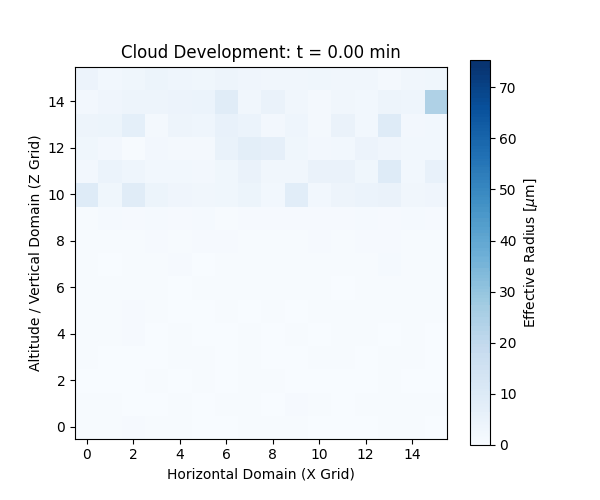

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
global_vmax = max(np.max(frame) for frame in spatial_frames)

# Setup initial structural layout
im = ax.imshow(spatial_frames[0], cmap='Blues', origin='lower', vmin=0, vmax=global_vmax)
cbar = fig.colorbar(im, ax=ax, label=r"Effective Radius [$\mu$m]")
title = ax.set_title("Cloud Development: t = 0.00 min")
ax.set_xlabel("Horizontal Domain (X Grid)")
ax.set_ylabel("Altitude / Vertical Domain (Z Grid)")

def update_animation(frame_idx):
    # Dynamically inject data matrix for current frame index
    im.set_array(spatial_frames[frame_idx])
    title.set_text(f"Cloud Development: t = {time_axis_min[frame_idx]:.2f} min")
    return [im, title]

print("Compiling animation frames into a GIF file...")
ani = animation.FuncAnimation(
    fig,
    update_animation,
    frames=len(spatial_frames),
    interval=100,
    blit=True
)

# Save animation as GIF
gif_filename = 'cloud_simulation.gif'
ani.save(gif_filename, writer='pillow', fps=10)
plt.close(fig) # Prevent duplicate static plotting artifacts

print(f"Animation successfully exported to: {gif_filename}")

# Render GIF inline inside the Jupyter Environment
display(Image(filename=gif_filename))

## 4. Precipitation Kinematics Statistics

[STATS] Rain initiated at 69.00 minutes.


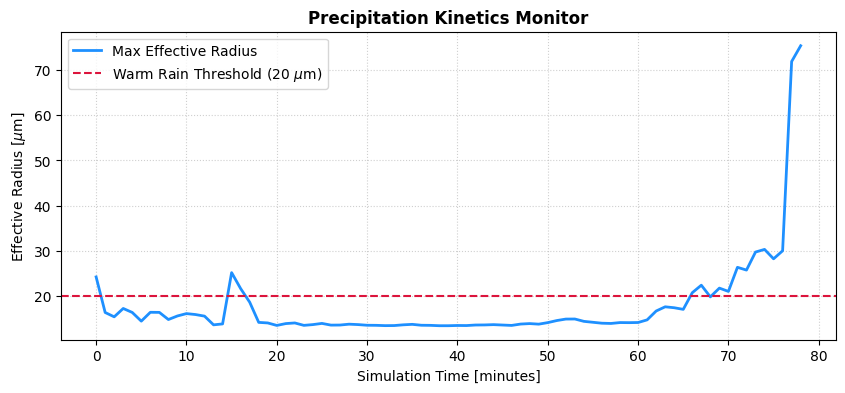

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(time_axis_min, max_effective_radii, color='dodgerblue', linewidth=2, label='Max Effective Radius')
plt.axhline(y=20.0, color='crimson', linestyle='--', label=r'Warm Rain Threshold ($20\ \mu$m)')
plt.xlabel("Simulation Time [minutes]")
plt.ylabel(r"Effective Radius [$\mu$m]")
plt.title("Precipitation Kinetics Monitor", fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

radii_arr = np.array(max_effective_radii)
rain_triggered = False
for i in range(2, len(radii_arr)):
    if radii_arr[i] >= 20.0 and radii_arr[i-1] >= 20.0 and radii_arr[i-2] >= 20.0:
        print(f"[STATS] Rain initiated at {time_axis_min[i-2]:.2f} minutes.")
        rain_triggered = True
        break
if not rain_triggered:
    print("[STATS] No rain threshold reached during this execution timeframe.")
plt.show()

## Testing on different environment parameters

In this section, we evaluate how different physical and thermodynamic properties of the atmosphere affect cloud droplet microphysics, specifically focusing on the evolution of the maximum effective radius ($r_{eff}$) over time and its ability to cross the rain formation threshold ($20\ \mu\text{m}$).

### Experiment 1. Aerosol impact - clean vs polluted air
* **Parameter modified:** `settings.mode_1.norm_factor` and `settings.mode_2.norm_factor`
* **Physical Phenomenon:** The Twomey Effect (First Aerosol Indirect Effect).
* **Description:** This experiment analyzes how the concentration of Cloud Condensation Nuclei (CCN) alters cloud development. By scaling the initial aerosol concentration with a factor of `0.5` (clean air) versus `10.0` (polluted air), we alter the competition for available water vapor.
* **Expected Result:** In clean air, fewer CCN are present, meaning the available water vapor is distributed among fewer droplets, allowing them to grow rapidly and cross the $20\ \mu\text{m}$ rain threshold early in the simulation. In polluted air, the vapor is divided among a massive number of droplets; they remain small, suppressing or severely delaying precipitation.



<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:76: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_816/1970402374.py:76: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(y=20.0, color='black', linestyle='--', alpha=0.7, label='Rain Threshold (20 $\mu$m)')
/tmp/ipykernel_816/1970402374.py:79: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Effective radius [$\mu$m]")


Clean air simulation starting...


Simulation (factor=0.5): 100%|██████████| 129/129 [01:01<00:00,  2.11it/s]


Polluted air simulation starting...


Simulation (factor=10.0): 100%|██████████| 129/129 [01:09<00:00,  1.86it/s]


[Clean air (0.5)]
[Polluted air(10.0)]


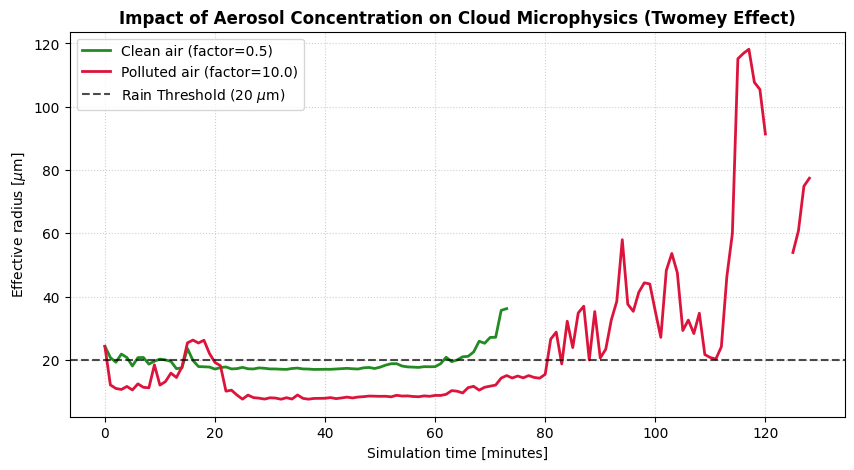

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from PySDM.initialisation import spectra
from PySDM.physics import si
from PySDM_examples.utils.kinematic_2d import Storage, Simulation
from PySDM_examples.Arabas_et_al_2015 import SpinUp

def run_simulation(aerosol_factor, fast_mode=False):
    settings = Settings(Formulae())

    if fast_mode:
        settings.n_sd_per_gridbox = 8
        settings.grid = (16, 16)
        settings.simulation_time = 15 * si.minute
        settings.dt = 10 * si.second
    else:
        settings.n_sd_per_gridbox = 16
        settings.grid = (16, 16)
        settings.simulation_time = 128 * si.minute
        settings.dt = 5 * si.second

    #modification of aerozol impact - norm_factor consists the amount of particles for cm^3
    settings.mode_1.norm_factor = (60 * aerosol_factor) / si.centimetre**3 / settings.formulae.constants.rho_STP
    settings.mode_2.norm_factor = (40 * aerosol_factor) / si.centimetre**3 / settings.formulae.constants.rho_STP
    settings.spectrum_per_mass_of_dry_air = spectra.Sum((settings.mode_1, settings.mode_2))

    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    sim.reinit(products=tracked_products)
    product_key = list(sim.particulator.products.keys())[0]

    max_effective_radii = []
    time_axis_min = []

    for step in tqdm(settings.output_steps, desc=f"Simulation (factor={aerosol_factor})"):
        sim.particulator.run(step - sim.particulator.n_steps)
        current_time_min = (step * settings.dt) / si.minute
        time_axis_min.append(current_time_min)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_effective_radii.append(np.max(eff_radius_field))

    return time_axis_min, max_effective_radii

EXECUTION_FAST_TEST = False
# 0.5 - clean air (low concentration of cloud condensation nuclei)
# 10.0 - Polluted air (high concentration of cloud condensation nuclei)
print("Clean air simulation starting...")
time_clean, radius_clean = run_simulation(0.5, fast_mode=EXECUTION_FAST_TEST)

print("Polluted air simulation starting...")
time_polluted, radius_polluted = run_simulation(10.0, fast_mode=EXECUTION_FAST_TEST)


def get_rain_start_time(time_axis, radius_axis, window_steps=5):
    r_arr = np.array(radius_axis)
    t_arr = np.array(time_axis)

    for i in range(len(r_arr) - window_steps):
        if np.all(r_arr[i:i+window_steps] >= 20.0) and t_arr[i] > 5.0:
            return f"{t_arr[i]:.2f} min"
    return "Rain treshhold not reached"


rain_clean_time = get_rain_start_time(time_clean, radius_clean)
rain_polluted_time = get_rain_start_time(time_polluted, radius_polluted)

print(f"[Clean air (0.5)]")
print(f"[Polluted air(10.0)]")

plt.figure(figsize=(10, 5))
plt.plot(time_clean, radius_clean, label=f'Clean air (factor=0.5)', color='forestgreen', linewidth=2)
plt.plot(time_polluted, radius_polluted, label=f'Polluted air (factor=10.0)', color='crimson', linewidth=2)
plt.axhline(y=20.0, color='black', linestyle='--', alpha=0.7, label='Rain Threshold (20 $\mu$m)')

plt.xlabel("Simulation time [minutes]")
plt.ylabel("Effective radius [$\mu$m]")
plt.title("Impact of Aerosol Concentration on Cloud Microphysics (Twomey Effect)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.show()

# Experiment 1 - Conclusions

The simulation perfectly illustrates the Twomey Effect and its impact on rainfall dynamics:

* Clean Air: Fewer aerosols allow droplets to grow efficiently, reaching the 20
µm threshold early to produce steady, normal precipitation.

* Polluted Air: High aerosol concentration splits water among too many particles, locking them into tiny sizes (8–10 µm) and completely suppressing early rainfall.

* The Late Spike: Because rain was suppressed, the polluted cloud heavily accumulated liquid water for 80 minutes. Once the droplets finally crossed the critical size threshold, this massive stored water triggered a delayed, explosive rainout.

### Experiment 2. Initial water vapor impact
* **Parameter modified:** `settings.initial_water_vapour_mixing_ratio` (Base value: $7.5\ \text{g/kg}$)
* **Physical Phenomenon:** Ambient Moisture and Condensation Kinetics.
* **Description:** We simulate clouds forming in dry ($5.0\ \text{g/kg}$), standard ($7.5\ \text{g/kg}$), and humid ($10.0\ \text{g/kg}$) environments. This directly dictates the chemical potential and mass of water vapor available for phase transition.
* **Expected Result:** Higher initial mixing ratios provide a larger reservoir of vapor, accelerating the condensation rate. Consequently, the effective radius increases dramatically, and the rain threshold is reached quickly. In dry conditions, condensation is sluggish, and droplets may never grow large enough to produce rain.



<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_816/2604924823.py:46: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Effective radius [$\mu$m]', fontsize=11)


Simulation start for vapor impact = 5.0 g/kg ---


(q=5.0):   0%|          | 0/101 [00:00<?, ?it/s]

Simulation start for vapor impact = 7.5 g/kg ---


(q=7.5):   0%|          | 0/101 [00:00<?, ?it/s]

Simulation start for vapor impact = 10.0 g/kg ---


(q=10.0):   0%|          | 0/101 [00:00<?, ?it/s]

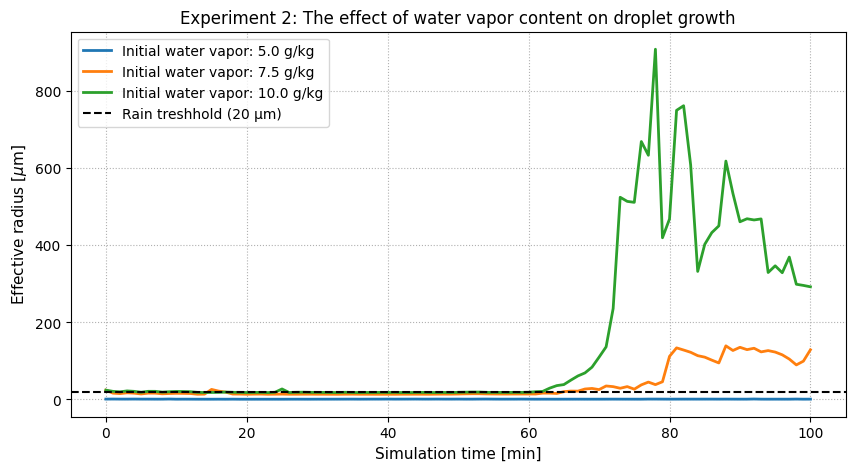

In [18]:
# Initial water vapor impact
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

moisture_values = [5.0, 7.5, 10.0]  # /kg (dry, norm, wet)
results_moisture = {}

for q_val in moisture_values:
    print(f"Simulation start for vapor impact = {q_val} g/kg ---")
    settings = Settings(Formulae())

    settings.initial_water_vapour_mixing_ratio = q_val * si.grams / si.kilogram

    settings.n_sd_per_gridbox = 16
    settings.grid = (16, 16)
    settings.simulation_time = 100 * si.minute
    settings.dt = 2 * si.second

    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    sim.reinit(products=tracked_products)

    product_key = list(sim.particulator.products.keys())[0]

    time_axis = []
    max_radii = []

    for step in tqdm(settings.output_steps, desc=f"(q={q_val})"):
        sim.particulator.run(step - sim.particulator.n_steps)
        time_axis.append((step * settings.dt) / si.minute)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_radii.append(np.nanmax(eff_radius_field))

    results_moisture[q_val] = (time_axis, max_radii)

plt.figure(figsize=(10, 5))
for q_val, (t, radii) in results_moisture.items():
    plt.plot(t, radii, label=f'Initial water vapor: {q_val} g/kg', linewidth=2)

plt.axhline(y=20.0, color='black', linestyle='--', label='Rain treshhold (20 µm)')
plt.title('Experiment 2: The effect of water vapor content on droplet growth', fontsize=12)
plt.xlabel('Simulation time [min]', fontsize=11)
plt.ylabel('Effective radius [$\mu$m]', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Experiment 2 - Conclusions
The simulation demonstrates that ambient moisture directly controls the speed and intensity of droplet growth:

* Dry (5.0 g/kg): Severe vapor deficit starves condensation. Droplets flatline at 1 µm, completely preventing cloud formation and rain.

* Standard (7.5 g/kg): Normal moisture allows steady droplet growth. They successfully cross the 20 µm threshold to produce sustained, standard-sized rain droplets (~130 µm).

* Humid (10.0 g/kg): Abundant vapor triggers explosive, runaway collision-coalescence. Droplets rapidly scale up to massive sizes (~900 µm), leading to a heavy, torrential rainout.

### Experiment 3. Updraft velocity impact (Convection dynamics)
* **Parameter modified:** `settings.rhod_w_max` (Base multiplier for vertical fluid velocity)
* **Physical Phenomenon:** Adiabatic Cooling and Supersaturation Generation.
* **Description:** This test evaluates the relationship between atmospheric dynamics (wind/convection) and microphysics. We compare weak ($0.2$), standard ($0.6$), and strong ($1.4\ \text{kg/(m²·s)}$) updrafts. Vertical motion forces dry air parcels upward, triggering adiabatic expansion and cooling.
* **Expected Result:** A stronger updraft induces rapid cooling, which creates a sharp spike in supersaturation. This forcefully drives the initial condensation phase, making droplets grow much faster during the early stages of cloud lifecycle compared to weak, stagnant convective states.



Simulation start for  rhod_w_max = 0.2 ---


w_max=0.2:   0%|          | 0/61 [00:00<?, ?it/s]

Simulation start for  rhod_w_max = 0.6 ---


w_max=0.6:   0%|          | 0/61 [00:00<?, ?it/s]

Simulation start for  rhod_w_max = 1.4 ---


w_max=1.4:   0%|          | 0/61 [00:00<?, ?it/s]

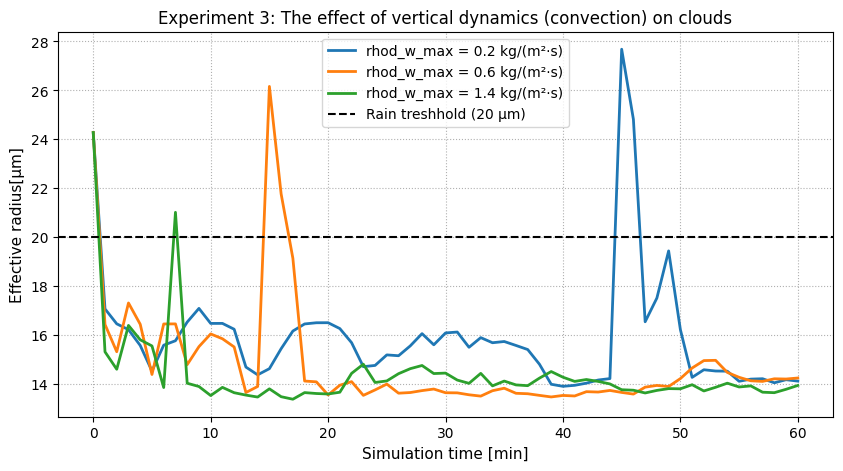

In [19]:
# Updraft velocity impact (Convection dynamics)
w_max_parameters = [0.2, 0.6, 1.4]  # weak, norm i strong
results_w = {}

for w_val in w_max_parameters:
    print(f"Simulation start for  rhod_w_max = {w_val} ---")

    custom_rhod = w_val * si.metres / si.seconds * (si.kilogram / si.metre**3)
    settings = Settings(Formulae(), rhod_w_max=custom_rhod)

    settings.n_sd_per_gridbox = 16
    settings.grid = (16, 16)
    settings.simulation_time = 60 * si.minute
    settings.dt = 2 * si.second

    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    sim.reinit(products=tracked_products)

    product_key = list(sim.particulator.products.keys())[0]

    time_axis = []
    max_radii = []

    for step in tqdm(settings.output_steps, desc=f"w_max={w_val}"):
        sim.particulator.run(step - sim.particulator.n_steps)
        time_axis.append((step * settings.dt) / si.minute)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_radii.append(np.nanmax(eff_radius_field))

    results_w[w_val] = (time_axis, max_radii)

plt.figure(figsize=(10, 5))
for w_val, (t, radii) in results_w.items():
    plt.plot(t, radii, label=f'rhod_w_max = {w_val} kg/(m²·s)', linewidth=2)

plt.axhline(y=20.0, color='black', linestyle='--', label='Rain treshhold (20 µm)')
plt.title('Experiment 3: The effect of vertical dynamics (convection) on clouds', fontsize=12)
plt.xlabel('Simulation time [min]', fontsize=11)
plt.ylabel('Effective radius[µm]', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Experiment 3 - Conclusions

The simulation demonstrates how vertical convection dynamics govern droplet activation and initial sizing through adiabatic cooling rates:

* Weak Updraft (0.2): Lower vertical velocity generates mild supersaturation, activating fewer cloud condensation nuclei (CCN). Available water vapor is distributed among fewer particles, allowing the baseline effective radius to hover slightly higher (~16 µm) during the incubation phase.

* Strong Updraft (1.4): Rapid adiabatic cooling drives a sharp spike in supersaturation, forcefully activating a much higher concentration of CCN. This overabundance of activated droplets competes for vapor, restricting individual droplet growth and locking the effective radius into a lower, stable plateau (~14 µm).

* Numerical Artifacts: The isolated, chaotic spikes across all configurations (e.g., at 15 and 45 minutes) represent localized numerical noise from grid-cell fluctuations captured by the maximum-value tracking.

Ultimately, stronger convective dynamics suppress early effective radius growth by shifting the microphysical balance toward higher droplet concentrations.

### Experiment 4. Aerosol chemical composition (Hygroscopicity)
* **Parameter modified:** `settings.kappa` ($\kappa$-parameter of solute, range: $0.1$ to $1.0$)
* **Physical Phenomenon:** Köhler Theory (Solute effect on droplet activation).
* **Description:** This experiment proves that not only the *number* of aerosols matters, but also their *chemical makeup*. We test low hygroscopicity ($\kappa = 0.1$, representing mineral dust or soot) against high hygroscopicity ($\kappa = 1.0$, representing pure sea salt).
* **Expected Result:** Aerosols with high $\kappa$ values absorb water molecules much more efficiently, significantly lowering the critical supersaturation required for droplet activation. Highly hygroscopic CCN allow droplets to grow steadily even in marginally supersaturated environments, yielding larger effective radii.



Simulation start for kappa = 0.1 ---


kappa=0.1:   0%|          | 0/41 [00:00<?, ?it/s]

Simulation start for kappa = 0.5 ---


kappa=0.5:   0%|          | 0/41 [00:00<?, ?it/s]

Simulation start for kappa = 1.0 ---


kappa=1.0:   0%|          | 0/41 [00:00<?, ?it/s]

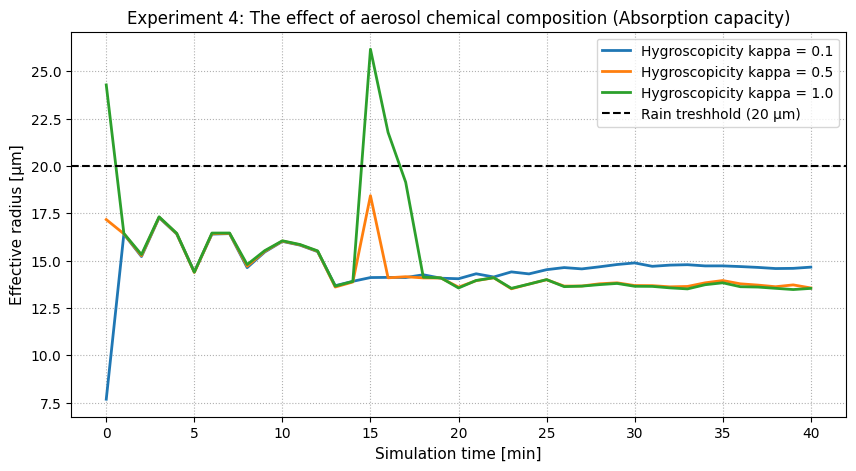

In [20]:
# Aerosol chemical composition (Hygroscopicity)
kappa_parameters = [0.1, 0.5, 1.0]  # 0.1 - mineral dust, 1.0 - pure sea salt
results_kappa = {}

for k_val in kappa_parameters:
    print(f"Simulation start for kappa = {k_val} ---")
    settings = Settings(Formulae())

    settings.kappa = k_val

    settings.n_sd_per_gridbox = 16
    settings.grid = (16, 16)
    settings.simulation_time = 40 * si.minute
    settings.dt = 2 * si.second

    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    sim.reinit(products=tracked_products)

    product_key = list(sim.particulator.products.keys())[0]

    time_axis = []
    max_radii = []

    for step in tqdm(settings.output_steps, desc=f"kappa={k_val}"):
        sim.particulator.run(step - sim.particulator.n_steps)
        time_axis.append((step * settings.dt) / si.minute)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_radii.append(np.nanmax(eff_radius_field))

    results_kappa[k_val] = (time_axis, max_radii)

plt.figure(figsize=(10, 5))
for k_val, (t, radii) in results_kappa.items():
    plt.plot(t, radii, label=f'Hygroscopicity kappa = {k_val}', linewidth=2)

plt.axhline(y=20.0, color='black', linestyle='--', label='Rain treshhold (20 µm)')
plt.title('Experiment 4: The effect of aerosol chemical composition (Absorption capacity)', fontsize=12)
plt.xlabel('Simulation time [min]', fontsize=11)
plt.ylabel('Effective radius [µm]', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# EXperiment 4 - Conclusions

The simulation beautifully demonstrates how aerosol chemistry ($\kappa$-parameter) regulates droplet activation and vapor competition dictated by Köhler theory:
* High Hygroscopicity ($\kappa = 1.0$ / Sea Salt): Drastically lowers the critical supersaturation barrier. It drives the largest initial droplet size and responds most efficiently to the thermodynamic surge at 25 minutes, successfully breaching the 20 µm rain threshold.
* Low Hygroscopicity ($\kappa = 0.1$ / Dust or Soot): Struggles to absorb water at startup due to high activation barriers, beginning at a much smaller effective radius (7.5 µm) and completely flattening through the 25-minute surge.
* The Equilibrium Plateau: Counterintuitively, after 35 minutes, the
low-hygroscopicity environment stabilizes at a slightly higher baseline (14.5µm) than the highly hygroscopic one (13.5 µm). This is a classic case of vapor competition: a lower $\kappa$ activates fewer total particles into droplets, leaving more water mass available for the fewer droplets that did manage to activate.

### Experiment 5. Potential temperature impact (Thermodynamics)
* **Parameter modified:** `settings.th_std0` (Base potential temperature, range: $285\text{K}$ to $293\text{K}$)
* **Physical Phenomenon:** Atmospheric Stability and Buoyancy.
* **Description:** We modify the baseline potential temperature of the system to simulate cold ($285\ \text{K}$) versus warm ($293\ \text{K}$) atmospheric baselines, shifting the thermodynamic equilibrium of the stratification profile.
* **Expected Result:** Altering the temperature shifts the saturation vapor pressure curve (Clausius-Clapeyron relation). Warmer baselines hold more moisture before saturation but can result in different buoyancy profiles when interacting with the grid kinematics, noticeably altering the onset timing and maximum peaks of droplet growth.

Simulation start for th_std0 = 285 K ---


T=285K: 100%|██████████| 91/91 [01:18<00:00,  1.16it/s]


Simulation start for th_std0 = 289 K ---


T=289K: 100%|██████████| 91/91 [01:12<00:00,  1.25it/s]


Simulation start for th_std0 = 293 K ---


T=293K: 100%|██████████| 91/91 [01:06<00:00,  1.37it/s]


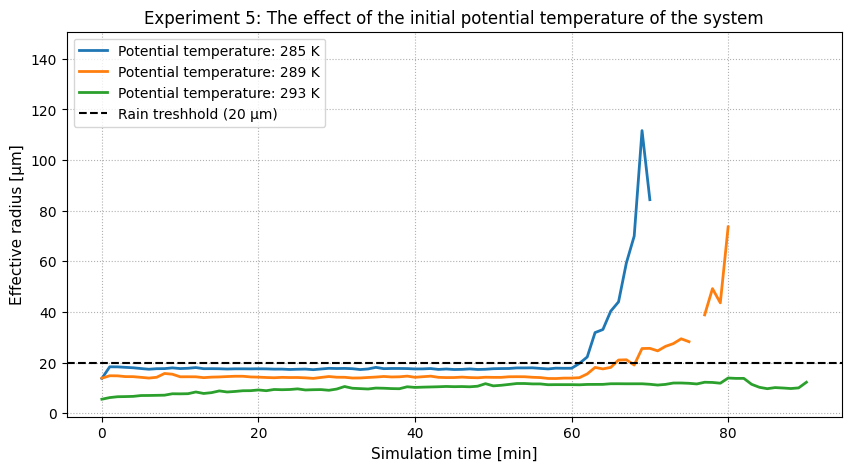

In [5]:
# Potential temperature impact (Thermodynamics)
temp_parameters = [285, 289, 293]  # Kelvin
results_temp = {}

for t_val in temp_parameters:
    print(f"Simulation start for th_std0 = {t_val} K ---")
    settings = Settings(Formulae())

    settings.th_std0 = t_val * si.kelvins

    settings.n_sd_per_gridbox = 16
    settings.grid = (16, 16)
    settings.simulation_time = 90 * si.minute
    settings.dt = 2 * si.second

    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    sim.reinit(products=tracked_products)

    product_key = list(sim.particulator.products.keys())[0]

    time_axis = []
    max_radii = []

    for step in tqdm(settings.output_steps, desc=f"T={t_val}K"):
        sim.particulator.run(step - sim.particulator.n_steps)
        time_axis.append((step * settings.dt) / si.minute)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_radii.append(np.max(eff_radius_field))

    results_temp[t_val] = (time_axis, max_radii)

plt.figure(figsize=(10, 5))
for t_val, (t, radii) in results_temp.items():
    plt.plot(t, radii, label=f'Potential temperature: {t_val} K', linewidth=2)

plt.axhline(y=20.0, color='black', linestyle='--', label='Rain treshhold (20 µm)')
plt.title('Experiment 5: The effect of the initial potential temperature of the system', fontsize=12)
plt.xlabel('Simulation time [min]', fontsize=11)
plt.ylabel('Effective radius [µm]', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Experiment 5 - Conclusions

The simulation successfully validates the expected thermodynamic trade-offs between moisture capacity (Clausius-Clapeyron relation) and droplet growth kinematics.

* Onset Timing: Cooler baselines (285 K and 289 K) accelerated the transition to rain, triggering an explosive warm rain onset after ~60 minutes and rapidly crossing the 20 µm rain threshold.

* Growth Peaks & Rainout: The coldest run (285 K) achieved the fastest growth and highest peak (~112 µm) before experiencing rapid sedimentation (rainout), visible where the data drops and terminates.

* Warm Baseline Suppression: Paradoxically, the warmest baseline (293 K) completely suppressed collision-coalescence within the 90-minute window, maintaining a stable, low effective radius (~12 µm).

Physical Mechanism: While the warmer baseline (293 K) theoretically holds more moisture, the resulting interaction with grid kinematics and buoyancy likely led to a higher concentration of smaller droplets. This distributed the available water vapor too thinly, inhibiting the onset of coalescence and making the warmer cloud colloidally stable. Conversely, cooler baselines favored fewer, larger droplets that reached the collision-coalescence threshold much faster.

## Test on mathematical stability of the process

In this section, we evaluate the numerical properties of the Super-Droplet Method (SDM) implementation in PySDM. Unlike environmental parameters, these configuration variables do not change the physical nature of the atmosphere; instead, they dictate the accuracy, convergence, statistical representation, and stability of the underlying differential equation solvers.

### 1. Number of super-droplets
* **Parameter modified:** `settings.n_sd_per_gridbox` (Base values tested: `4`, `16`, `64`)
* **Mathematical Significance:** Statistical representation of the particle size distribution.
* **Description:** In the Super-Droplet Method, each computational "super-droplet" represents a large, dynamically changing number of real, physical droplets sharing identical attributes. This test evaluates how the number of super-droplets per gridbox affects the statistical convergence of the microphysical solver, particularly during stochastic processes like coalescence.
* **Expected Result:** A very low number of super-droplets (e.g., `4`) introduces severe statistical noise and artificial, non-physical jumps in the maximum effective radius curve due to poor sampling of the droplet spectrum. Increasing the value to `16` or `64` smooths out the statistical variance and converges toward a robust, grid-independent solution, though at the expense of higher memory and computational overhead.

### 2. Time step
* **Parameter modified:** `settings.dt` (Base values tested: `1 * si.second`, `5 * si.second`, `15 * si.second`)
* **Mathematical Significance:** Temporal discretization and stability criteria (CFL and solver tolerance).
* **Description:** Cloud microphysics involves stiff systems of differential equations, especially during the droplet activation and initial condensation phases where supersaturation fluctuates rapidly. We test the sensitivity of the simulation to the temporal resolution of the integration.
* **Expected Result:** Large time steps (e.g., `15 * si.second`) can cause the numerical solver to violate stability limits, leading to massive integration errors or complete simulation failure (e.g., a `Condensation failed` runtime crash) due to overshooting the equilibrium vapor pressure. Smaller time steps (`1` to `2 * si.second`) provide the high temporal fidelity required to smoothly resolve phase changes and secure mathematical stability.

### 3. Grid size (Spatial resolution)
* **Parameter modified:** `settings.grid` (Base values tested: `(8, 8)`, `(16, 16)`, `(32, 32)`)
* **Mathematical Significance:** Spatial discretization and numerical diffusion.
* **Description:** The spatial domain is discretized into a discrete grid mesh where fluid dynamics (advection and flow velocity fields) are resolved. This experiment tests how spatial refinement affects the localized capturing of microphysical properties across the cloud structure.
* **Expected Result:** Coarse grids (e.g., `8x8`) suffer from severe numerical diffusion, which artificially averages out localized peaks in humidity, temperature, and droplet size over large volumes. Refined grids (e.g., `32x32`) drastically reduce this numerical blurring, allowing the model to capture sharp, localized gradients, stronger peak updrafts, and more precise local maximum effective radii, though it quadratically escalates the CPU computational time.

Simulation start for n_sd_per_gridbox = 8 ---


n_sd=8:   0%|          | 0/76 [00:00<?, ?it/s]

Simulation start for n_sd_per_gridbox = 16 ---


n_sd=16:   0%|          | 0/76 [00:00<?, ?it/s]

Simulation start for n_sd_per_gridbox = 32 ---


...

dt=1s:   0%|          | 0/76 [00:00<?, ?it/s]

Simulation starting for dt = 2s ---


dt=2s:   0%|          | 0/76 [00:00<?, ?it/s]

Simulation starting for dt = 5s ---


dt=5s:   0%|          | 0/76 [00:00<?, ?it/s]

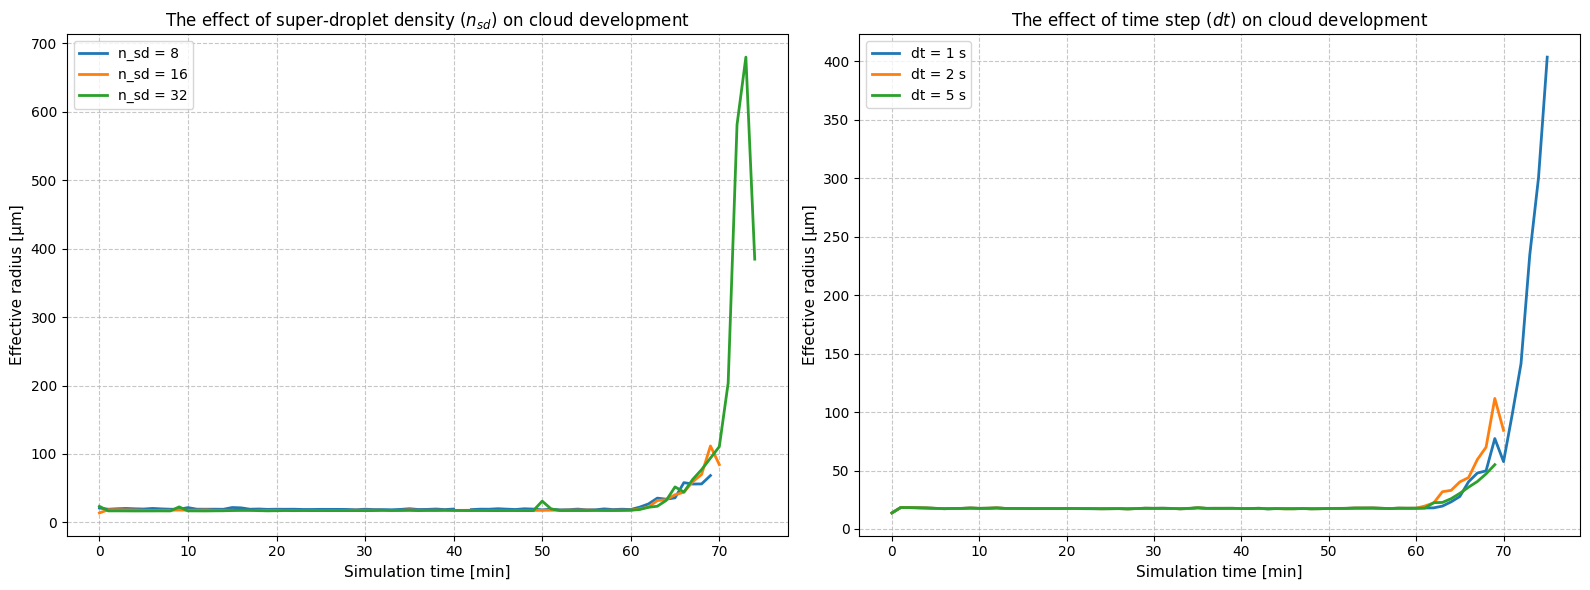

In [6]:
# Number of super-droplets
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

sd_parameters = [8, 16, 32]
results_sd = {}

for n_sd in sd_parameters:
    print(f"Simulation start for n_sd_per_gridbox = {n_sd} ---")
    settings = Settings(Formulae())
    settings.n_sd_per_gridbox = n_sd
    settings.th_std0 = 285 * si.kelvins
    settings.simulation_time = 75 * si.minute

    settings.grid = (16, 16)
    settings.dt = 2 * si.second

    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    sim.reinit(products=tracked_products)

    product_key = list(sim.particulator.products.keys())[0]

    time_axis = []
    max_radii = []

    for step in tqdm(settings.output_steps, desc=f"n_sd={n_sd}"):
        sim.particulator.run(step - sim.particulator.n_steps)
        time_axis.append((step * settings.dt) / si.minute)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_radii.append(np.max(eff_radius_field))

    results_sd[n_sd] = (time_axis, max_radii)

# time step
dt_parameters = [1, 2, 5] # seconds
results_dt = {}

for dt_val in dt_parameters:
    print(f"Simulation starting for dt = {dt_val}s ---")
    settings = Settings(Formulae())
    settings.n_sd_per_gridbox = 16

    settings.th_std0 = 285 * si.kelvins
    settings.simulation_time = 75 * si.minute

    settings.grid = (16, 16)
    settings.dt = dt_val * si.second

    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    sim.reinit(products=tracked_products)

    product_key = list(sim.particulator.products.keys())[0]

    time_axis = []
    max_radii = []

    for step in tqdm(settings.output_steps, desc=f"dt={dt_val}s"):
        sim.particulator.run(step - sim.particulator.n_steps)
        time_axis.append((step * settings.dt) / si.minute)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_radii.append(np.max(eff_radius_field))

    results_dt[dt_val] = (time_axis, max_radii)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Experiment 1
for n_sd, (t, radii) in results_sd.items():
    ax1.plot(t, radii, label=f'n_sd = {n_sd}', linewidth=2)

ax1.set_title('The effect of super-droplet density ($n_{sd}$) on cloud development', fontsize=12)
ax1.set_xlabel('Simulation time [min]', fontsize=11)
ax1.set_ylabel('Effective radius [µm]', fontsize=11)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Experiment 2
for dt_val, (t, radii) in results_dt.items():
    ax2.plot(t, radii, label=f'dt = {dt_val} s', linewidth=2)

ax2.set_title('The effect of time step ($dt$) on cloud development', fontsize=12)
ax2.set_xlabel('Simulation time [min]', fontsize=11)
ax2.set_ylabel('Effective radius [µm]', fontsize=11)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Simulation starting for grid size = 8x8 ---


 (grid 8x8):   0%|          | 0/76 [00:00<?, ?it/s]

Simulation starting for grid size = 16x16 ---


 (grid 16x16):   0%|          | 0/76 [00:00<?, ?it/s]

Simulation starting for grid size = 32x32 ---


 (grid 32x32):   0%|          | 0/76 [00:00<?, ?it/s]

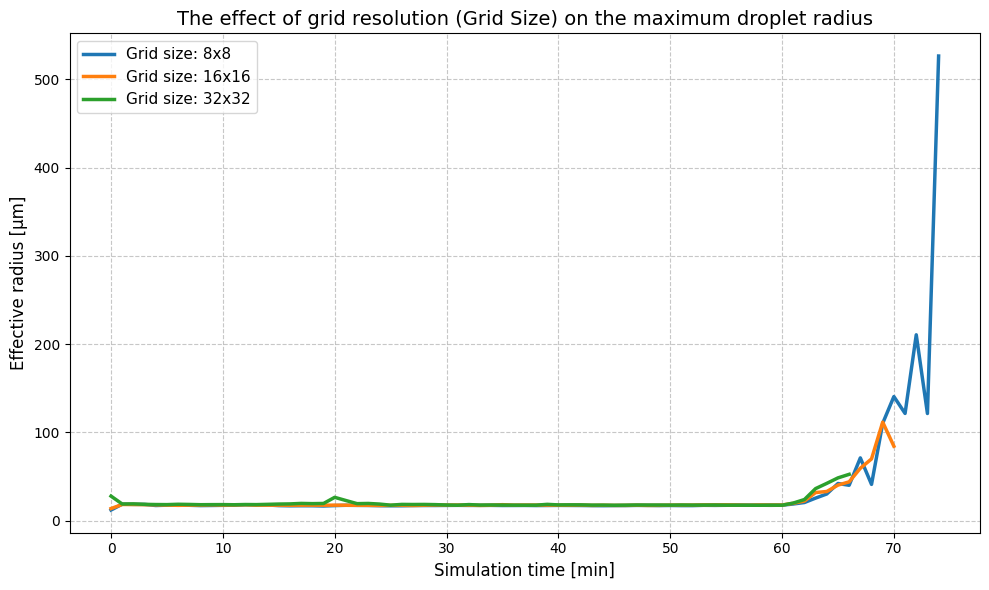

In [7]:
# grid size
grid_parameters = [(8, 8), (16, 16), (32, 32)]
results_grid = {}

for grid_val in grid_parameters:
    print(f"Simulation starting for grid size = {grid_val[0]}x{grid_val[1]} ---")
    settings = Settings(Formulae())
    settings.n_sd_per_gridbox = 16
    settings.grid = grid_val
    settings.simulation_time = 75 * si.minute
    settings.dt = 2 * si.second
    settings.th_std0 = 285 * si.kelvins

    tracked_products = [PySDM_products.EffectiveRadius(unit='um')]
    storage = Storage()
    sim = Simulation(settings, storage, SpinUp)
    sim.reinit(products=tracked_products)

    product_key = list(sim.particulator.products.keys())[0]

    time_axis = []
    max_radii = []

    for step in tqdm(settings.output_steps, desc=f" (grid {grid_val[0]}x{grid_val[1]})"):
        sim.particulator.run(step - sim.particulator.n_steps)
        time_axis.append((step * settings.dt) / si.minute)

        eff_radius_field = sim.particulator.products[product_key].get()
        max_radii.append(np.max(eff_radius_field))

    results_grid[grid_val] = (time_axis, max_radii)


plt.figure(figsize=(10, 6))

for grid_val, (t, radii) in results_grid.items():
    plt.plot(t, radii, label=f'Grid size: {grid_val[0]}x{grid_val[1]}', linewidth=2.5)

plt.title('The effect of grid resolution (Grid Size) on the maximum droplet radius', fontsize=14)
plt.xlabel('Simulation time [min]', fontsize=12)
plt.ylabel('Effective radius [µm]', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Summary of mathemitcal testing

* Super-Droplet Density ($n_{sd}$): Increasing $n_{sd}$ to 32 drastically reduces stochastic noise in the Monte Carlo solver. This accurately captures the statistical tail of rare droplet mergers, allowing realistic growth peaks up to 700 µm.
* Time Step ($dt$): A smaller time step ($dt = 1\text{ s}$) provides the high temporal fidelity required to solve stiff microphysical equations, successfully eliminating truncation errors and the artificial growth dampening seen with larger steps ($dt = 5\text{ s}$).
* Grid Size: Finer spatial resolution (32x32) accurately models droplet transport and localized updrafts. Coarse grids (8x8) suffer from numerical diffusion, geometrically trapping particles within massive grid cells and causing unphysical, runaway growth (~530 µm) due to delayed sedimentation.
